<a href="https://colab.research.google.com/github/takumi-maker/dmd/blob/main/markov_trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import pandas as pd
import math
import statistics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import statsmodels.api as sm

In [ ]:
df_1 = pd.read_csv("通貨データセット1.csv")
df_1 = df_1.drop(df_1.columns[0], axis=1)
columns_len = len(df_1.columns)
length = len(df_1)
df_1
y_df = df_1
y_df = y_df.drop('USDJPY',axis=1)
y_df = y_df.drop('EURJPY',axis=1)
y_df = y_df.drop('EUDUSD',axis=1)
y_df = y_df.drop('AUDUSD',axis=1)
y_df = y_df.drop('AUDJPY',axis=1)
y_df = y_df.drop('AUDEUR',axis=1)
y_df = y_df.drop('GBPUSD',axis=1)
#y_df = y_df.drop('EURGBP',axis=1)
y_df

,EURGBP
0,0.89712
1,0.90499
2,0.90436
3,0.90345
4,0.90032
...,...
769,0.86656
770,0.86800
771,0.86973
772,0.86841


In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(y_df)
# 検定結果の表示
print('ADF Statistic: %f' % result[0])
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))
print('p-value: %f' % result[1])

ADF Statistic: -3.544882
	1%: -3.439
	5%: -2.865
	10%: -2.569
p-value: 0.006907


<Axes: >

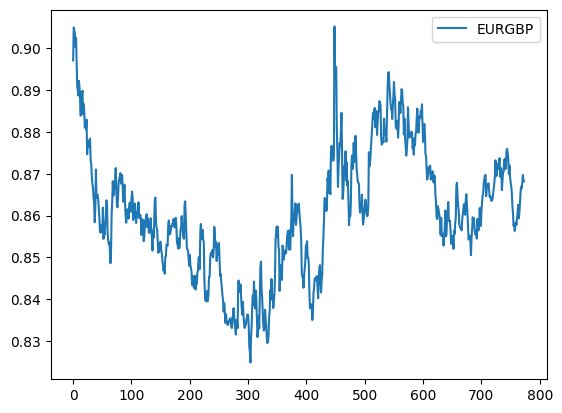

In [ ]:
y_df.plot()

In [ ]:
class MSSCARCH:
  def __init__(self, upsilon2=2.0):
    self.upsilon2 = upsilon2
    self.F = np.array([[1,1,0],
                       [0,1,0],
                       [0,0,0]],dtype=float)
    self.G = np.array([[1,1,0],
                       [0,1,0],
                       [0,0,1]],dtype=float)
    self.H = np.array([[1,0,1]],dtype=float)
    self.params_ = None

  def _unpack_params(self, theta):
    tau2 = np.exp(theta[0])
    gamma0 = np.exp(theta[1])
    gamma1 = np.exp(theta[2]) + gamma0
    alpha = 1.0 / (1.0 + np.exp(-theta[3]))
    p00 = 1.0 / (1.0 + np.exp(-theta[4]))
    p11 = 1.0 / (1.0 + np.exp(-theta[5]))
    return tau2, gamma0, gamma1, alpha, p00, p11

  def _pack_params(self, tau2, gamma0, gamma1, alpha, p00, p11):
    theta = np.zeros(6)
    theta[0] = np.log(tau2)
    theta[1] = np.log(gamma0)
    theta[2] = np.log(gamma1 - gamma0)
    theta[3] = np.log(alpha / (1.0 - alpha + 1e-10))
    theta[4] = np.log(p00 / (1.0 - p00 + 1e-10))
    theta[5] = np.log(p11 / (1.0 - p11 + 1e-10))
    return theta

  def _run_filter(self, y, tau2, gamma0, gamma1, alpha, p00, p11):
    N = len(y)
    upsilon2 = self.upsilon2
    F = self.F
    G = self.G
    H = self.H

    trans_prob = np.array([[p00, 1-p00],
                           [1-p11, p11]])

    x_filt = [None, None]
    P_filt = [None, None]

    x_init = np.array([y[0], 0.0, 0.0])
    P_init = np.diag([1.0, 1.0, 1.0])

    for j in range(2):
      x_filt[j] = x_init.copy()
      P_filt[j] = P_init.copy()

    prob_filt = np.array([(1-p11) / (2-p00-p11),
                          (1-p00) / (2-p00-p11)])

    log_lik = 0.0

    x_filt_store = np.zeros((N, 3))
    delta_t_store = np.zeros(N)
    prob_s1_store = np.zeros(N)
    delta_t_pred_store = np.zeros(N)

    for n in range(1, N):
      x_collapsed = prob_filt[0] * x_filt[0] + prob_filt[1] * x_filt[1]

      eps_mean = x_collapsed[2]
      eps_var = (prob_filt[0] * P_filt[0][2,2] + prob_filt[1] * P_filt[1][2,2]
                 + prob_filt[0] * (x_filt[0][2] - eps_mean)**2
                 + prob_filt[1] * (x_filt[1][2] - eps_mean)**2)
      E_eps2 = eps_mean**2 + eps_var

      h = np.zeros(2)
      h[0] =gamma0 + alpha *E_eps2
      h[1] =gamma1 + alpha *E_eps2
      h =np.maximum(h, 1e-8)

      x_pred_ij = {}
      P_pred_ij = {}
      x_upd_ij = {}
      P_upd_ij = {}
      f_ij = {}

      for i in range(2):
        for j in range(2):
          Q = np.diag([tau2, upsilon2 * j, h[j]])

          x_pred = F @ x_filt[i]
          P_pred = F @ P_filt[i] @ F.T + G @ Q @ G.T

          x_pred_ij[(i,j)] = x_pred
          P_pred_ij[(i,j)] = P_pred

          innov = y[n] - (H @ x_pred)[0]
          S = (H @ P_pred @ H.T )[0,0]
          S = max(S, 1e-8)

          K = P_pred @ H.T / S

          x_upd = x_pred + K.flatten() * innov
          P_upd = (np.eye(3) - K @ H) @ P_pred

          x_upd_ij[(i,j)] = x_upd
          P_upd_ij[(i,j)] = P_upd

          f_ij[(i,j)] = norm.pdf(innov, 0, np.sqrt(S))


      joint_prob = np.zeros((2,2))
      for i in range(2):
        for j in range(2):
          joint_prob[i,j] = trans_prob[i,j] * prob_filt[i]

      marginal_lik = 0.0
      joint_post = np.zeros((2,2))
      for i in range(2):
        for j in range(2):
          marginal_lik += joint_prob[i,j] * f_ij[(i,j)]

      if marginal_lik < 1e-300:
        marginal_lik = 1e-300

      log_lik += np.log(marginal_lik)

      for i in range(2):
        for j in range(2):
          joint_post[i,j] = joint_prob[i,j] * f_ij[(i,j)] / marginal_lik

      new_prob_filt = np.zeros(2)
      for j in range(2):
        new_prob_filt[j] = joint_post[0,j] + joint_post[1,j]

      new_x_filt = [None, None]
      new_P_filt = [None, None]
      for j in range(2):
        if new_prob_filt[j] < 1e-15:
          new_x_filt[j] = x_upd_ij[(0,j)]
          new_P_filt[j] = P_upd_ij[(0,j)]
        else:
          xj = np.zeros(3)
          for i in range(2):
            xj += joint_post[i,j] * x_upd_ij[(i,j)]
          xj /= new_prob_filt[j]
          new_x_filt[j] = xj


          Pj = np.zeros((3,3))
          for i in range(2):
            diff = xj - x_upd_ij[(i,j)]
            Pj += joint_post[i,j] * (P_upd_ij[(i,j)]+np.outer(diff, diff) )
          Pj /= new_prob_filt[j]
          new_P_filt[j] = Pj

      x_filt = new_x_filt
      P_filt = new_P_filt
      prob_filt = new_prob_filt
      #print(x_filt)
      #print(P_filt)
      #print(prob_filt)

      x_collapsed = prob_filt[0] * x_filt[0] + prob_filt[1] * x_filt[1]
      x_filt_store[n] = x_collapsed
      delta_t_store[n] = x_collapsed[1]
      prob_s1_store[n] = prob_filt[1]

      x_pred_all = np.zeros(3)
      for k in range(2):
        for j_idx in range(2):
          w = trans_prob[j_idx,k] * prob_filt[j_idx]
          x_pred_all += w * (F @ x_filt[j_idx])

      delta_t_pred_store[n] = x_pred_all[1]

    return log_lik, x_filt_store, delta_t_store, delta_t_pred_store, prob_s1_store

  def _neg_log_lik(self, theta, y):
    tau2, gamma0, gamma1, alpha, p00, p11 = self._unpack_params(theta)

    try:
      ll, _, _, _, _ = self._run_filter(y, tau2, gamma0, gamma1, alpha, p00, p11)
    except:
      return 1e10

    if np.isnan(ll) or np.isinf(ll):
      return 1e10

    return -ll

  def fit(self, y, verbose=True):
    theta0 = self._pack_params(tau2=2.0, gamma0=1.0, gamma1=4.0, alpha=0.5, p00 =0.99, p11=0.8)

    result = minimize(self._neg_log_lik, theta0, args=(y,),
                      method='Powell' #Powell

                      )
    #options={'maxiter': 10000, 'xatol': 1e-6, 'fatol': 1e-6},
    "#bounds=[[-np.inf, np.inf], [0.00001, 10000000], [0.00001, 10000000],[0, np.inf],[0.0, 1],[0.0, 1]]"

    self.params_ = self._unpack_params(result.x)
    tau2, gamma0, gamma1, alpha, p00, p11 = self.params_

    if verbose:
      print(f'tau^2 = {tau2:.4f}')
      print(f'gamma0 = {gamma0:.4f}')
      print(f'gamma1 = {gamma1:.4f}')
      print(f'alpha = {alpha:.4f}')
      print(f'p00 = {p00:.4f}')
      print(f'p11 = {p11:.4f}')
      print(f'log likelihood = {-result.fun:.4f}')
      print(f'AIC = {result.fun*2 + 2 * 6:.4f}')



    return self.params_

  def filter(self, y,params=None):
    if params is None:
      params = self.params_
    tau2, gamma0, gamma1, alpha, p00, p11 = params
    return self._run_filter(y, tau2, gamma0, gamma1, alpha, p00, p11)

  def trading_signal(self, delta_t_pred):
    return np.where(delta_t_pred >= 0, -1, 1)


def evaluate_trading(y_raw, signals, formation_end):
  log_returns = np.diff(np.log(y_raw))
  sim_start = formation_end
  sim_returns = []

  for n in range(sim_start, len(log_returns)):
    r = signals[n] * log_returns[n]
    sim_returns.append(r)

  sim_returns = np.array(sim_returns)
  cum_return = np.sum(sim_returns)
  return sim_returns, cum_return

In [ ]:
from sklearn.linear_model import LinearRegression
import statsmodels
import statsmodels.api
import matplotlib.pyplot as plt
from sklearn import preprocessing
import cvxpy as cp

magic_num = 180 #180
estimate_num = 150
predict_time = 30 #30


df_array = y_df.to_numpy().squeeze()
y_syn = np.log(df_array)
#y_syn = df_array


for i in range(1,5):
  formation_end = 100*i

  y_formation = y_syn[:formation_end]
  model = MSSCARCH(upsilon2=2.0)
  params = model.fit(y_formation)
  l1, x_filt, delta_t_filt, delta_t_pred, prob_s1 = model.filter(y_syn, params)
  print(delta_t_pred)

  signals = model.trading_signal(delta_t_pred)
  price = np.exp(y_syn)
  #price = y_syn

  sim_returns, cum_return = evaluate_trading(price, signals, formation_end)
  signal_changes = np.sum(np.abs(np.diff(signals[formation_end:]))>0)

  print(cum_return)
  print(signal_changes)


tau^2 = 0.0000
gamma0 = 0.0000
gamma1 = 1.0421
alpha = 0.1116
p00 = 0.9655
p11 = 0.0000
log likelihood = 346.1618
AIC = -680.3236
[ 0.00000000e+00  4.15688513e-03  7.95728748e-04 -6.59972494e-04
 -2.61312165e-03  2.74281071e-04 -2.91223207e-03 -4.73358991e-03
 -3.64226168e-03 -2.81041154e-03 -1.00357330e-03 -7.73857357e-04
 -1.16073121e-03 -1.62331978e-03 -9.48327804e-04 -7.74675145e-04
 -4.20507060e-04 -5.97985147e-04 -5.25095540e-04 -5.65850772e-04
 -7.79659466e-04 -7.93451731e-04 -8.43354901e-04 -7.57342746e-04
 -9.27751752e-04 -9.28477270e-04 -9.23713103e-04 -9.36942994e-04
 -8.96535252e-04 -8.34381718e-04 -8.62935354e-04 -8.89931786e-04
 -9.45587318e-04 -9.69899088e-04 -9.95463829e-04 -1.03221378e-03
 -1.05230216e-03 -1.10507563e-03 -1.10270541e-03 -1.06126667e-03
 -1.06239469e-03 -1.04426408e-03 -1.01624986e-03 -1.00110823e-03
 -9.99847942e-04 -1.01280511e-03 -1.04434250e-03 -1.05029524e-03
 -1.04540340e-03 -1.04624718e-03 -1.03636266e-03 -7.04574240e-04
 -9.87209076e-04 -8.57636

In [ ]:
print(signal_changes)

0


In [ ]:
formation_end = 313
y_formation = y_syn[:formation_end]
model = MSSCARCH(upsilon2=2.0)
params = model.fit(y_formation)
l1, x_filt, delta_t_filt, delta_t_pred, prob_s1 = model.filter(y_syn, params)

signals = model.trading_signal(delta_t_pred)
price = np.exp(y_syn/100)

sim_returns, cum_return = evaluate_trading(price, signals, formation_end)
signal_changes = np.sum(np.abs(np.diff(signals[formation_end:]))>0)


tau^2 = 0.0000
gamma0 = 0.0000
gamma1 = 1.5569
alpha = 0.4980
p00 = 0.9881
p11 = 0.8004
log likelihood = 955.3416
AIC = -1898.6831


In [ ]:
df_1 = pd.read_csv("原油先物データセット.csv")
df_1 = df_1.drop(df_1.columns[0], axis=1)
columns_len = len(df_1.columns)
length = len(df_1)
df_1
y_df = df_1
y_df = y_df.drop('OILNYMEX',axis=1)
#y_df = y_df.drop('OILICE',axis=1)

y_df

,OILICE
0,55.99
1,55.66
2,56.58
3,56.06
4,56.42
...,...
1158,66.60
1159,65.79
1160,66.84
1161,67.67
